# Lab 10 : Model Selction

## Import Commomn Libraries

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
from sklearn import preprocessing
%matplotlib inline

C:\ProgramData\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


### About dataset

This dataset is about past loans. The **Loan_train.csv** data set includes details of 346 customers whose loan are already paid off or defaulted. It includes following fields:

| Field          | Description                                                                           |
| -------------- | ------------------------------------------------------------------------------------- |
| Loan_status    | Whether a loan is paid off on in collection                                           |
| Principal      | Basic principal loan amount at the                                                    |
| Terms          | Origination terms which can be weekly (7 days), biweekly, and monthly payoff schedule |
| Effective_date | When the loan got originated and took effects                                         |
| Due_date       | Since it’s one-time payoff schedule, each loan has one single due date                |
| Age            | Age of applicant                                                                      |
| Education      | Education of applicant                                                                |
| Gender         | The gender of applicant                                                               |

## Import Training Dataset

In [2]:
df = pd.read_csv('loan_train.csv')
df.head()

,Unnamed: 0,Unnamed: 0.1,loan_status,Principal,terms,effective_date,due_date,age,education,Gender
0,0,0,PAIDOFF,1000,30,9/8/2016,10/7/2016,45,High School or Below,male
1,2,2,PAIDOFF,1000,30,9/8/2016,10/7/2016,33,Bechalor,female
2,3,3,PAIDOFF,1000,15,9/8/2016,9/22/2016,27,college,male
3,4,4,PAIDOFF,1000,30,9/9/2016,10/8/2016,28,college,female
4,6,6,PAIDOFF,1000,30,9/9/2016,10/8/2016,29,college,male


## EDA Steps

In [3]:
df.shape

(346, 10)

In [4]:
df.columns

Index(['Unnamed: 0', 'Unnamed: 0.1', 'loan_status', 'Principal', 'terms',
       'effective_date', 'due_date', 'age', 'education', 'Gender'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      346 non-null    int64 
 1   Unnamed: 0.1    346 non-null    int64 
 2   loan_status     346 non-null    object
 3   Principal       346 non-null    int64 
 4   terms           346 non-null    int64 
 5   effective_date  346 non-null    object
 6   due_date        346 non-null    object
 7   age             346 non-null    int64 
 8   education       346 non-null    object
 9   Gender          346 non-null    object
dtypes: int64(5), object(5)
memory usage: 27.2+ KB


In [6]:
df.describe()

,Unnamed: 0,Unnamed: 0.1,Principal,terms,age
count,346.000000,346.000000,346.000000,346.000000,346.000000
mean,202.167630,202.167630,943.641618,22.653179,30.939306
std,115.459715,115.459715,109.425530,7.991006,6.039418
min,0.000000,0.000000,300.000000,7.000000,18.000000
25%,107.250000,107.250000,900.000000,15.000000,27.000000
50%,204.500000,204.500000,1000.000000,30.000000,30.000000
75%,298.750000,298.750000,1000.000000,30.000000,35.000000
max,399.000000,399.000000,1000.000000,30.000000,51.000000


In [7]:
df.describe(include = 'object')

,loan_status,effective_date,due_date,education,Gender
count,346,346,346,346,346
unique,2,7,23,4,2
top,PAIDOFF,9/11/2016,10/10/2016,High School or Below,male
freq,260,166,90,151,294


### Convert to date time object

In [8]:
df['due_date'] = pd.to_datetime(df['due_date'])
df['effective_date'] = pd.to_datetime(df['effective_date'])
df.head()

,Unnamed: 0,Unnamed: 0.1,loan_status,Principal,terms,effective_date,due_date,age,education,Gender
0,0,0,PAIDOFF,1000,30,2016-09-08,2016-10-07,45,High School or Below,male
1,2,2,PAIDOFF,1000,30,2016-09-08,2016-10-07,33,Bechalor,female
2,3,3,PAIDOFF,1000,15,2016-09-08,2016-09-22,27,college,male
3,4,4,PAIDOFF,1000,30,2016-09-09,2016-10-08,28,college,female
4,6,6,PAIDOFF,1000,30,2016-09-09,2016-10-08,29,college,male


# Data visualization and pre-processing Steps

Let’s see how many of each class is in our data set

In [9]:
df['loan_status'].value_counts()

PAIDOFF       260
COLLECTION     86
Name: loan_status, dtype: int64

260 people have paid off the loan on time while 86 have gone into collection

Let's plot some columns to underestand data better:

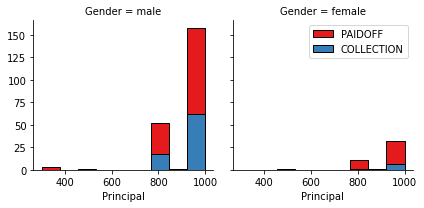

In [10]:
import seaborn as sns

bins = np.linspace(df.Principal.min(), 
                   df.Principal.max(), 10)
g = sns.FacetGrid(df, col="Gender", 
                  hue="loan_status", 
                  palette="Set1", 
                  col_wrap=2)
g.map(plt.hist, 
      'Principal', 
      bins=bins, 
      ec="k")

g.axes[-1].legend()
plt.show()

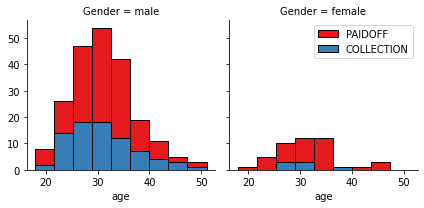

In [11]:
bins = np.linspace(df.age.min(), 
                   df.age.max(), 10)
g = sns.FacetGrid(df, 
                  col="Gender", 
                  hue="loan_status", 
                  palette="Set1", 
                  col_wrap=2)
g.map(plt.hist, 
      'age', 
      bins=bins, 
      ec="k")

g.axes[-1].legend()
plt.show()

## Pre-processing:  Feature selection/extraction


### Let's look at the day of the week people get the loan

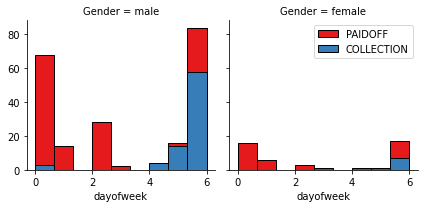

In [12]:
df['dayofweek'] = df['effective_date'].dt.dayofweek
bins = np.linspace(df.dayofweek.min(), 
                   df.dayofweek.max(), 
                   10)
g = sns.FacetGrid(df, 
                  col="Gender", 
                  hue="loan_status", 
                  palette="Set1", 
                  col_wrap=2)
g.map(plt.hist, 
      'dayofweek', 
      bins=bins, 
      ec="k")
g.axes[-1].legend()
plt.show()


We see that people who get the loan at the end of the week don't pay it off, so let's use Feature binarization to set a threshold value less than day 4

In [13]:
df['weekend'] = df['dayofweek'].apply(lambda x: 1 if (x>3)  else 0)
df.head()

,Unnamed: 0,Unnamed: 0.1,loan_status,Principal,terms,effective_date,due_date,age,education,Gender,dayofweek,weekend
0,0,0,PAIDOFF,1000,30,2016-09-08,2016-10-07,45,High School or Below,male,3,0
1,2,2,PAIDOFF,1000,30,2016-09-08,2016-10-07,33,Bechalor,female,3,0
2,3,3,PAIDOFF,1000,15,2016-09-08,2016-09-22,27,college,male,3,0
3,4,4,PAIDOFF,1000,30,2016-09-09,2016-10-08,28,college,female,4,1
4,6,6,PAIDOFF,1000,30,2016-09-09,2016-10-08,29,college,male,4,1


## Convert Categorical features to numerical values

Let's look at gender:

In [14]:
df.groupby(['Gender'])['loan_status'].value_counts(normalize=True)

Gender  loan_status
female  PAIDOFF        0.865385
        COLLECTION     0.134615
male    PAIDOFF        0.731293
        COLLECTION     0.268707
Name: loan_status, dtype: float64

86 % of female pay there loans while only 73 % of males pay there loan

Let's convert male to 0 and female to 1:

In [15]:
df['Gender'].replace(to_replace=['male','female'], value=[0,1],inplace=True)
df.head()

,Unnamed: 0,Unnamed: 0.1,loan_status,Principal,terms,effective_date,due_date,age,education,Gender,dayofweek,weekend
0,0,0,PAIDOFF,1000,30,2016-09-08,2016-10-07,45,High School or Below,0,3,0
1,2,2,PAIDOFF,1000,30,2016-09-08,2016-10-07,33,Bechalor,1,3,0
2,3,3,PAIDOFF,1000,15,2016-09-08,2016-09-22,27,college,0,3,0
3,4,4,PAIDOFF,1000,30,2016-09-09,2016-10-08,28,college,1,4,1
4,6,6,PAIDOFF,1000,30,2016-09-09,2016-10-08,29,college,0,4,1


## One Hot Encoding

#### How about education?

In [16]:
df.groupby(['education'])['loan_status'].value_counts(normalize=True)

education             loan_status
Bechalor              PAIDOFF        0.750000
                      COLLECTION     0.250000
High School or Below  PAIDOFF        0.741722
                      COLLECTION     0.258278
Master or Above       COLLECTION     0.500000
                      PAIDOFF        0.500000
college               PAIDOFF        0.765101
                      COLLECTION     0.234899
Name: loan_status, dtype: float64

#### Features before One Hot Encoding

In [17]:
df[['Principal','terms','age','Gender','education']].head()

,Principal,terms,age,Gender,education
0,1000,30,45,0,High School or Below
1,1000,30,33,1,Bechalor
2,1000,15,27,0,college
3,1000,30,28,1,college
4,1000,30,29,0,college


#### Use one hot encoding technique to conver categorical varables to binary variables and append them to the feature Data Frame

In [18]:
Feature = df[['Principal','terms','age','Gender','weekend']]
Feature = pd.concat([Feature,pd.get_dummies(df['education'])], axis=1)
Feature.drop(['Master or Above'], axis = 1,inplace=True)
Feature.head()
Feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Principal             346 non-null    int64
 1   terms                 346 non-null    int64
 2   age                   346 non-null    int64
 3   Gender                346 non-null    int64
 4   weekend               346 non-null    int64
 5   Bechalor              346 non-null    uint8
 6   High School or Below  346 non-null    uint8
 7   college               346 non-null    uint8
dtypes: int64(5), uint8(3)
memory usage: 14.7 KB


### Feature Selection

Let's define feature sets, X:

In [19]:
X = Feature
X[0:5]

,Principal,terms,age,Gender,weekend,Bechalor,High School or Below,college
0,1000,30,45,0,0,0,1,0
1,1000,30,33,1,0,1,0,0
2,1000,15,27,0,0,0,0,1
3,1000,30,28,1,1,0,0,1
4,1000,30,29,0,1,0,0,1


What are our lables? Create Output Variable

In [20]:
y = df['loan_status']
y[0:5]
d = {'COLLECTION':0,'PAIDOFF' : 1}
y = y.map(d)

## Normalize Data

Data Standardization give data zero mean and unit variance (technically should be done after train test split)

In [21]:
X= preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[ 0.51578458,  0.92071769,  2.33152555, -0.42056004, -1.20577805,
        -0.38170062,  1.13639374, -0.86968108],
       [ 0.51578458,  0.92071769,  0.34170148,  2.37778177, -1.20577805,
         2.61985426, -0.87997669, -0.86968108],
       [ 0.51578458, -0.95911111, -0.65321055, -0.42056004, -1.20577805,
        -0.38170062, -0.87997669,  1.14984679],
       [ 0.51578458,  0.92071769, -0.48739188,  2.37778177,  0.82934003,
        -0.38170062, -0.87997669,  1.14984679],
       [ 0.51578458,  0.92071769, -0.3215732 , -0.42056004,  0.82934003,
        -0.38170062, -0.87997669,  1.14984679]])

### Split the Data into Training and Testing Set

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, 
                                                    random_state=42)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (276, 8) (276,)
Test set: (70, 8) (70,)


# Classification

Now, it is your turn, use the training set to build an accurate model. Then use the test set to report the accuracy of the model
You should use the following algorithm:

*   K Nearest Neighbor(KNN)
*   Decision Tree
*   Support Vector Machine
*   Logistic Regression

\__ Notice:\__

*   You can go above and change the pre-processing, feature selection, feature-extraction, and so on, to make a better model.
*   You should use either scikit-learn, Scipy or Numpy libraries for developing the classification algorithms.
*   You should include the code of the algorithm in the following cells.


# K Nearest Neighbor(KNN)

Notice: You should find the best k to build the model with the best accuracy.\

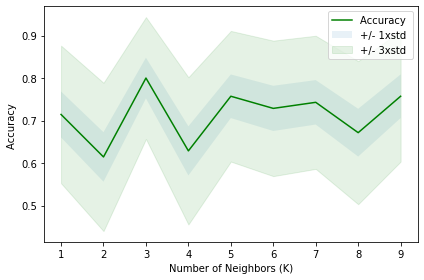

The best accuracy was with 0.8 with k= 3


In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
Ks = 10
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))

for n in range(1,Ks):  
    knn1 = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat=knn1.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(y_test, yhat)

    std_acc[n-1]=np.std(yhat==y_test)/np.sqrt(yhat.shape[0])

mean_acc
plt.plot(range(1,Ks),mean_acc,'g')
plt.fill_between(range(1,Ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc, alpha=0.10)
plt.fill_between(range(1,Ks),mean_acc - 3 * std_acc,mean_acc + 3 * std_acc, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()
print( "The best accuracy was with", mean_acc.max(), "with k=", mean_acc.argmax()+1) 

### Parameter Tunning using Grid Search Cv

In [24]:
from sklearn.model_selection import GridSearchCV
k_range = list(range(1, 31))
weight_options = ['uniform', 'distance']
pow = [1,2]
param_grid = dict(n_neighbors=k_range, 
                  weights=weight_options,
                  p = pow)
knn_gs = KNeighborsClassifier()
grid_k = GridSearchCV(knn_gs, 
                    param_grid, 
                    cv=10, 
                    scoring='accuracy')
grid_k.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [25]:
print("Tuned Hyperparameters :", grid_k.best_params_)
print("Accuracy :",grid_k.best_score_)

Tuned Hyperparameters : {'n_neighbors': 29, 'p': 2, 'weights': 'uniform'}
Accuracy : 0.7505291005291005


In [54]:
knn1 = KNeighborsClassifier(n_neighbors= 29, p = 2, weights = 'uniform')

In [55]:
knn1.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=29)

In [56]:
yhat = knn1.predict(X_test)

In [57]:
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
a1 = jaccard_score(y_test,yhat,pos_label=1)
b1 = f1_score(y_test, yhat, average='weighted')
c1 = accuracy_score(y_test, yhat)
print('The jaccard_score of the KNN for k = 7 classifier on train data is {:.2f}'.format(a1))
print('The F1-score of the KNN for k = 7 classifier on train data is {:.2f}'.format(b1))
print('The Accuracy_score of the KNN for k = 7 classifier on train data is {:.2f}'.format(c1))

The jaccard_score of the KNN for k = 7 classifier on train data is 0.68
The F1-score of the KNN for k = 7 classifier on train data is 0.68
The Accuracy_score of the KNN for k = 7 classifier on train data is 0.69


# Decision Tree

### Parameter Tuning For Decision tree to find best tree

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {'criterion' :['gini', 'entropy'],
              'max_features': ['auto', 'sqrt', 'log2'],
              'ccp_alpha': [0.1, .01, .001],
              'max_depth' : [5, 6, 7, 8, 9],
              
             }
tree_clas = DecisionTreeClassifier(random_state=1024)
grid_search = GridSearchCV(estimator=tree_clas, param_grid=param_grid, cv=5, verbose=True)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=1024),
             param_grid={'ccp_alpha': [0.1, 0.01, 0.001],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8, 9],
                         'max_features': ['auto', 'sqrt', 'log2']},
             verbose=True)

### Find the best parameters

In [31]:
print("Tuned Hyperparameters :", grid_search.best_params_)
print("Accuracy :",grid_search.best_score_)

Tuned Hyperparameters : {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'auto'}
Accuracy : 0.742922077922078


In [32]:
Loan_Tree = grid_search.best_estimator_
print(Loan_Tree)

DecisionTreeClassifier(ccp_alpha=0.001, max_depth=5, max_features='auto',
                       random_state=1024)


### Train the best model using Training Data

In [33]:
Loan_Tree.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=0.001, max_depth=5, max_features='auto',
                       random_state=1024)

In [34]:
predTree = Loan_Tree.predict(X_test)

In [35]:
a2 = jaccard_score(y_test, predTree,pos_label=1)
b2 = f1_score(y_test, predTree, average='weighted')
c2 = accuracy_score(y_test, predTree)
print("The accuraccy of (Loan_ tree) DecisionTrees's {:.2f} ".format(c2))
print('The jaccard_score of the (Loan_ tree) DecisionTrees classifier on train data is {:.2f}'.format(a2))
print('The F1-score of the (Loan_ tree) DecisionTrees classifier on train data is {:.2f}'.format(b2))

The accuraccy of (Loan_ tree) DecisionTrees's 0.66 
The jaccard_score of the (Loan_ tree) DecisionTrees classifier on train data is 0.64
The F1-score of the (Loan_ tree) DecisionTrees classifier on train data is 0.67


# Support Vector Machine

### Parameter Tunning For SVM using GridSerachCV

In [36]:
from sklearn.svm import SVC
param_grid = {'C': [0.1,1, 10, 100], 
              'gamma': [1,0.1,0.01,0.001],
              'kernel': ['rbf', 'poly', 'sigmoid']}
grid_s = GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
grid_s.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, k

[CV] END ....................C=1, gamma=0.01, kernel=sigmoid; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ......................C=1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ......................C=1, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ...................C=1, gamma=0.001, kernel=sigmoid; total time=   0.0s
[CV] END ...................

[CV] END ..................C=100, gamma=0.01, kernel=sigmoid; total time=   0.0s
[CV] END ..................C=100, gamma=0.01, kernel=sigmoid; total time=   0.0s
[CV] END ..................C=100, gamma=0.01, kernel=sigmoid; total time=   0.0s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ....................C=100, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ....................C=100, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ....................C=100, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ....................C=100, gamma=0.001, kernel=poly; total time=   0.0s
[CV] END ...................

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'poly', 'sigmoid']},
             verbose=2)

In [37]:
print("Tuned Hyperparameters :", grid_s.best_params_)
print("Accuracy :",grid_s.best_score_)

Tuned Hyperparameters : {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy : 0.7574675324675324


In [38]:
svm = SVC(probability=True,C=0.1, gamma=1, kernel='sigmoid')
print(svm)

SVC(C=0.1, gamma=1, kernel='sigmoid', probability=True)


In [39]:
svm.fit(X_train, y_train)

SVC(C=0.1, gamma=1, kernel='sigmoid', probability=True)

In [40]:
yhat_s = svm.predict(X_test)

In [41]:
a3 = jaccard_score(y_test, yhat_s,pos_label=1)
b3 = f1_score(y_test, yhat_s, average='weighted')
c3 = accuracy_score(y_test, yhat_s)
print('The accuracy of the svm classifier on training data is {:.2f} out of 1'.format(svm.score(X_train, y_train)))
print('The accuracy of the svm classifier on test data is {:.2f} out of 1'.format(svm.score(X_test, y_test)))
print('The jaccard_score of the SVM classifier on train data is {:.2f}'.format(a3))
print('The F1-score of the SVM classifier on train data is {:.2f}'.format(b3))
print('The accuracy-score of the SVM classifier on train data is {:.2f}'.format(c3))

The accuracy of the svm classifier on training data is 0.70 out of 1
The accuracy of the svm classifier on test data is 0.73 out of 1
The jaccard_score of the SVM classifier on train data is 0.71
The F1-score of the SVM classifier on train data is 0.72
The accuracy-score of the SVM classifier on train data is 0.73


# Logistic Regression

### Parameter Tunning using Grid Serch CV

In [42]:
from sklearn.linear_model import LogisticRegression
parameters = {
    'penalty' : ['l1','l2'], 
    'C'       : np.logspace(-3,3,7),
    'solver'  : ['newton-cg', 'lbfgs', 'liblinear'],
}
logreg = LogisticRegression()
clf = GridSearchCV(logreg,                    # model
                   param_grid = parameters,   # hyperparameters
                   scoring='accuracy',        # metric for scoring
                   cv=10)                     # number of folds
clf.fit(X_train,y_train)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
140 fits failed out of a total of 420.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1461, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 449, in _check_solver
    % (solver, penalty)


GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'penalty': ['l1', 'l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear']},
             scoring='accuracy')

In [43]:
print("Tuned Hyperparameters :", clf.best_params_)
print("Accuracy :",clf.best_score_)

Tuned Hyperparameters : {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy : 0.7612433862433863


In [44]:
log_reg = clf.best_estimator_
log_reg.fit(X_train,y_train)

LogisticRegression(C=0.001, solver='liblinear')

In [45]:
yhat_l = log_reg.predict(X_test)

In [46]:
a4 = jaccard_score(y_test, yhat_l,pos_label=1)
b4 = f1_score(y_test, yhat_l, average='weighted')
c4 = accuracy_score(y_test, yhat_l)

print('The jaccard_score of the logistic regression classifier on train data is {:.2f}'.format(a4))
print('The F1-score of the logistic regression classifier on train data is {:.2f}'.format(b4))
print('The accuracy_score of the logistic regression classifier on train data is {:.2f}'.format(c4))


The jaccard_score of the logistic regression classifier on train data is 0.69
The F1-score of the logistic regression classifier on train data is 0.70
The accuracy_score of the logistic regression classifier on train data is 0.70


# Model Evaluation 

In [58]:
result_df=pd.DataFrame({'Model':['KNN','Decision Tree','SVM','Logistic Regression'],
                    'Jaccard Score' : [a1,a2,a3,a4],
                    'F1 Score' : [b1,b2,b3,b4],
                    'Accuracy Score':[c1,c2,c3,c4]})

In [59]:
print(result_df)

                 Model  Jaccard Score  F1 Score  Accuracy Score
0                  KNN       0.676471  0.676383        0.685714
1        Decision Tree       0.636364  0.672222        0.657143
2                  SVM       0.712121  0.724746        0.728571
3  Logistic Regression       0.686567  0.695772        0.700000


# using K-fold cross validation

KNN: 0.753175 (0.059460)
DT: 0.728042 (0.082328)
SVM: 0.739286 (0.087455)
LR: 0.749735 (0.055885)


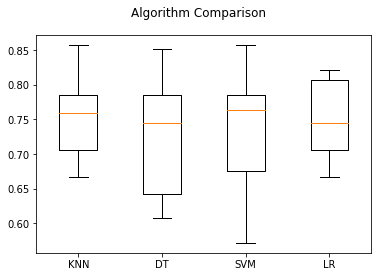

In [60]:
from sklearn import model_selection 
# prepare configuration for cross validation test harness
seed = 42
# prepare models
models = []
models.append(('KNN', knn1))
models.append(('DT', Loan_Tree ))
models.append(('SVM', svm))
models.append(('LR', log_reg))
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name,model in models:
    kfold = model_selection.KFold(n_splits=10,random_state=seed,shuffle=True)
    cv_results = model_selection.cross_val_score(model,X_train,y_train,cv=kfold,scoring=scoring)
    results.append(cv_results)
    names.append(name)
    
result_mean =[]
result_std = []
i = 0
for name,model in models:
    msg = "%s: %f (%f)" % (name,results[i].mean(), 
                           results[i].std())
    result_mean.append(results[i].mean()*100)
    result_std.append(results[i].std())
    i = i+1
    print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

## Ploting ROC_AUC Curce

In [50]:
#d = {'COLLECTION':0,'PAIDOFF' : 1}
#y_test = y_test.map(d)

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score

# Instantiate the classfiers and make a list
classifiers = [knn1, 
               Loan_Tree, 
               svm, 
               log_reg]
model = ['KNN',
         'Decision Tree',
         'SVM',
         'Logistic Regression'] 
# Define a result table as a DataFrame
result_table = pd.DataFrame(columns=['model', 'fpr','tpr','auc'])

# Train the models and record the results
for cls in classifiers:
    model = cls.fit(X_train, y_train)
    yproba = model.predict_proba(X_test)[::,1]
    fpr, tpr, _ = roc_curve(y_test,  yproba)
    auc = roc_auc_score(y_test, yproba)
    
    result_table = result_table.append({'model':cls.__class__.__name__,
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}, ignore_index=True)

# Set name of the classifiers as index labels
result_table.set_index('model', inplace=True)


In [52]:
print(result_table)

                                                                      fpr  \
model                                                                       
KNeighborsClassifier    [0.0, 0.0, 0.07142857142857142, 0.071428571428...   
DecisionTreeClassifier  [0.0, 0.21428571428571427, 0.2857142857142857,...   
SVC                     [0.0, 0.0, 0.0, 0.07142857142857142, 0.0714285...   
LogisticRegression      [0.0, 0.0, 0.07142857142857142, 0.071428571428...   

                                                                      tpr  \
model                                                                       
KNeighborsClassifier    [0.0, 0.10714285714285714, 0.19642857142857142...   
DecisionTreeClassifier  [0.0, 0.16071428571428573, 0.48214285714285715...   
SVC                     [0.0, 0.017857142857142856, 0.25, 0.25, 0.2857...   
LogisticRegression      [0.0, 0.017857142857142856, 0.0178571428571428...   

                             auc  
model                             
KNei

### Plot The Figure

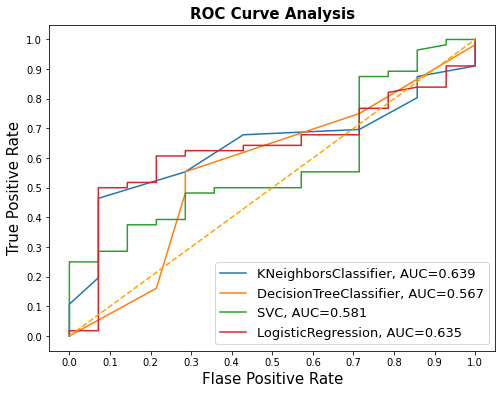

In [53]:
fig = plt.figure(figsize=(8,6))

for i in result_table.index:
    plt.plot(result_table.loc[i]['fpr'], 
             result_table.loc[i]['tpr'], 
             label="{}, AUC={:.3f}".format(i, result_table.loc[i]['auc']))
    
plt.plot([0,1], [0,1], color='orange', linestyle='--')

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("Flase Positive Rate", fontsize=15)

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True Positive Rate", fontsize=15)

plt.title('ROC Curve Analysis', fontweight='bold', fontsize=15)
plt.legend(prop={'size':13}, loc='lower right')

plt.show()